# Overview of Intermediate Goal: Signal Analysis 

For the intermediate goal, this project intends to use a Short-Time Fourier Transform (STFT) and Wavelet Transform (WT) to extract frequency-domained features. Many common audio features rely on the frequency spectrum, which is obtained through STFT. A study entitled "Voice-Based Early Diagnosis of Parkinson’s Disease Using Spectrogram Features and AI Models" by Quamar et al. (2025) uses features such as Spectral Centroid, Spectral Bandwidth, Spectral Contrast, and Mel-Frequency Ceptral Coefficients (MFCCs) to detect Parkinson's Disease. 

A WT will also be used to extract time-frequency statistics such as mean coefficient, variance, and energy per scale to help capture irregular tremors.

For the FFT, the Librosa python library will be used as it converts time-domain audio signals into frequency-domain representations (spectrograms). It uses FFT as backends for frequency calculations. Further, PyWavelets will also be used for wavelet transforms as it is commonly used for time-frequency decomposition. 

By the end of this section, an EDA will be performed to show differences between a healthy person's voice and a PD candidate's voice. 

Brief Definitions of Features: 
1) Spectral Centoid - brightness of sound 
2) Spectral Bandwidth - spread of frequencies 
3) Spectral Contrast - harmonic vs noise differences 
4) MFCCs - vocal tract characteristics
5) Mean Coefficient of WT - average signal strength 
6) Variance of Coefficients of WT - how much the signal fluctuates (tremor) 
7) Energy per scale of WT - total power of the signal of that frequency scale 



In [2]:
%pip install librosa
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [107]:
# setting up the notebook 

import librosa 
import librosa.display 
import pywt
import pandas as pd 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt 
import os 
from glob import glob
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier



In [7]:
'''Code for Feature Extraction'''

# Setting targets for the audio files
data_map = {
    "pd_dataset/HC_AH/*.wav": 0,    # Healthy Control
    "pd_dataset/PD_AH/*.wav": 1     # Parkinson's Disease
}

features_list = []

for path_pattern, target in data_map.items():
    audio_files = glob(path_pattern)
    print(f"Processing {len(audio_files)} files for target: {target}")

    # Setting up a progress bar
    for file in tqdm(audio_files, desc=f"Target {target}", unit="file"):
        
        x, sr = librosa.load(file, sr=None)
        stft = np.abs(librosa.stft(x))

        # Feature Extraction
        mfcc1 = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc1, axis=1)

        spectral_centroid = librosa.feature.spectral_centroid(y=x, sr=sr)
        centroid_mean = np.mean(spectral_centroid)

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=sr)
        bandwidth_mean = np.mean(spectral_bandwidth)

        spectral_contrast = librosa.feature.spectral_contrast(S=stft, sr=sr, n_bands=3)
        contrast_mean = np.mean(spectral_contrast, axis=1)

        # Combine features + label
        feature_row = np.hstack([
            mfcc_mean,
            centroid_mean,
            bandwidth_mean,
            contrast_mean,
            target
        ])

        # Append everything 
        features_list.append(feature_row)

# Column Labels
mfcc_names = [f"mfcc_{i}" for i in range(1, 14)]
spectral_names = ["spectral_centroid", "spectral_bandwidth"]
contrast_names = [f"contrast_band_{i}" for i in range(1, 5)]
column_labels = mfcc_names + spectral_names + contrast_names + ["target"]

# Create DataFrame
df = pd.DataFrame(features_list, columns=column_labels)

print("Extraction Complete. Dataframe Shape:", df.shape)
df

Processing 41 files for target: 0


Target 0:   0%|                                                                               | 0/41 [00:00<?, ?file/s]C:\Users\jlgel\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
Target 0: 100%|██████████████████████████████████████████████████████████████████████| 41/41 [00:03<00:00, 13.64file/s]


Processing 40 files for target: 1


Target 1: 100%|██████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 63.74file/s]


Extraction Complete. Dataframe Shape: (81, 20)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,contrast_band_1,contrast_band_2,contrast_band_3,contrast_band_4,target
0,-34.671783,46.427185,-63.750423,-37.945095,-5.174286,-7.978308,-11.592722,7.337579,9.517365,-9.009621,-21.090189,-7.455282,-6.077338,1104.893589,741.075744,24.806168,27.109300,29.031058,29.002101,0.0
1,-51.353390,88.080132,-59.384941,-22.281412,-16.072655,-1.175686,-12.314146,-1.524578,0.616782,-12.499595,-9.319973,-13.819527,-2.889428,932.762445,658.452860,26.253622,25.037222,22.921611,27.640020,0.0
2,-75.293953,69.476532,-39.382324,-20.257771,-0.351907,0.462403,-16.158535,-2.635781,-15.651364,-16.545940,-8.706078,-8.037354,-8.123940,921.438546,725.465544,15.140855,30.398796,27.958255,29.106558,0.0
3,-32.810532,64.750412,-44.563965,-25.503115,-10.679801,0.391478,-19.562962,4.752218,0.198751,-25.886776,-19.472654,-13.636947,-1.386326,1023.948012,788.648102,27.203380,27.528240,27.385805,27.324650,0.0
4,-69.802628,41.698448,-55.650742,-45.029232,2.411105,8.187595,-28.289539,14.828458,-2.618405,-4.690909,-24.383987,-14.418140,7.071354,1229.625748,821.848030,22.416047,24.273961,26.204595,27.436695,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,-175.285690,38.995998,-36.874859,-34.680492,22.312656,-9.648567,-16.332352,5.128305,-9.038811,4.585876,-15.523121,3.245329,-15.609770,1349.832602,974.581309,23.384316,24.872782,25.014791,26.969288,1.0
77,-182.891846,55.136276,-31.717503,-49.519794,0.165608,11.415182,-20.467979,7.393897,1.737478,-1.373219,-22.136343,-15.020916,3.766758,1118.477422,826.369012,26.053243,25.043910,28.198584,28.063913,1.0
78,-64.881943,-20.999617,-51.011646,20.657621,-10.907411,-4.179439,15.597313,-22.053579,-18.473082,22.235464,-17.968420,-8.981183,-8.029469,1580.412201,718.134821,13.688773,28.211730,27.847201,30.238863,1.0
79,-80.320450,83.589615,-23.517599,-19.847649,-7.128909,-2.610546,-28.880053,-3.599473,10.541465,-11.141140,-20.561964,-25.042875,-2.383995,908.430621,783.307474,25.792100,25.800800,23.652257,25.577980,1.0


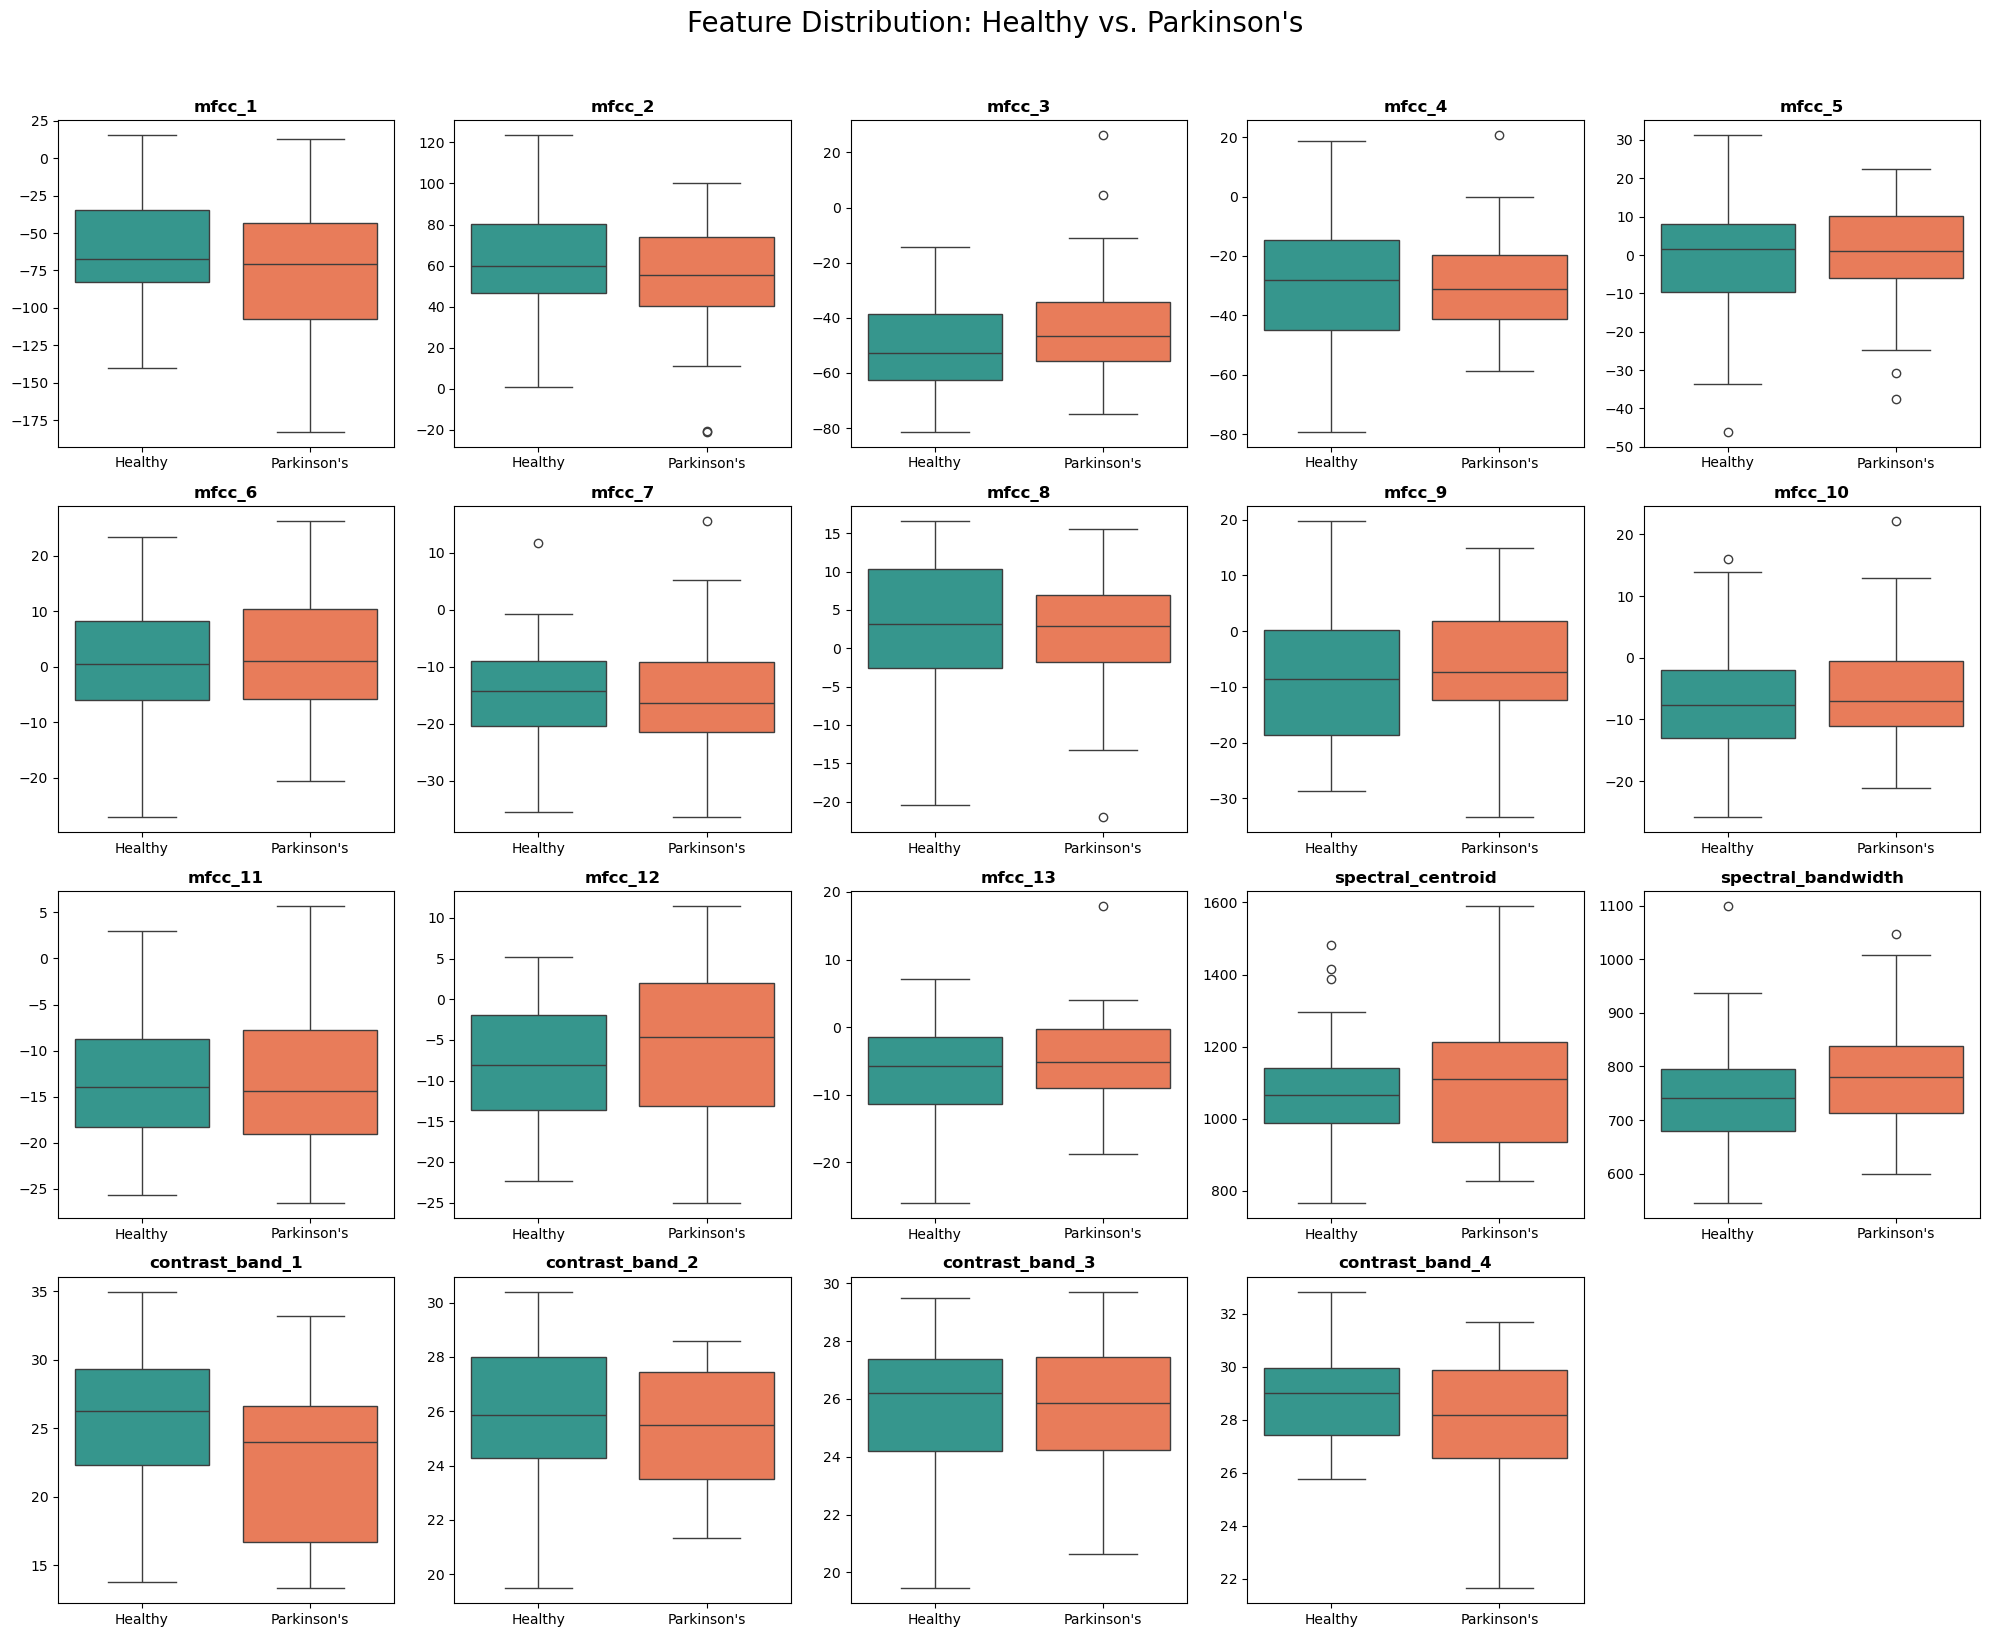

In [13]:
'''Code for EDA'''

# Convert labels for the legend/axis
df["target_label"] = df["target"].map({0: "Healthy", 1: "Parkinson's"})

# Get all features except the target 
feature_cols = [col for col in df.columns if col not in ['target', 'target_label']]

plt.figure(figsize=(20, 16))

# Define a color palette 
palette = { "Healthy": "#26a69a", "Parkinson's": "#ff7043" }

# Set up the graph format 
for i, feature in enumerate(feature_cols):
    plt.subplot(4, 5, i + 1)

    # plot 
    
    sns.boxplot(
        x="target_label", 
        y=feature, 
        data=df,
        palette=palette,
        hue="target_label", 
        legend=False
    )
    
    plt.title(feature, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distribution: Healthy vs. Parkinson's", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Overview of Advanced Goal: Machine Learning 

For the advanced goal, this notebook intends to perform KNN, Random Forest, and logistic regression to classify the audio samples and evaluate which machine learning model most accurately distinguishes between healthy individuals and those with Parkinson's disease. 

The dataframe that combines all features from Step 1 and Step 2 will be fed into these models. Beyond simple classification, we analyze feature importance to pinpoint specific biomarkers that drive the model's decision. 

The performance of these models will further be measured not only by accuracy, but also through a detailed confusion matrix that will better ensure symptomatic individuals are correctly identified for further medical intervention. 

In [115]:
'''Logistic regression with scaling for reproducibility''' 

X = df.select_dtypes(include=['number']).drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.52


C:\Users\jlgel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


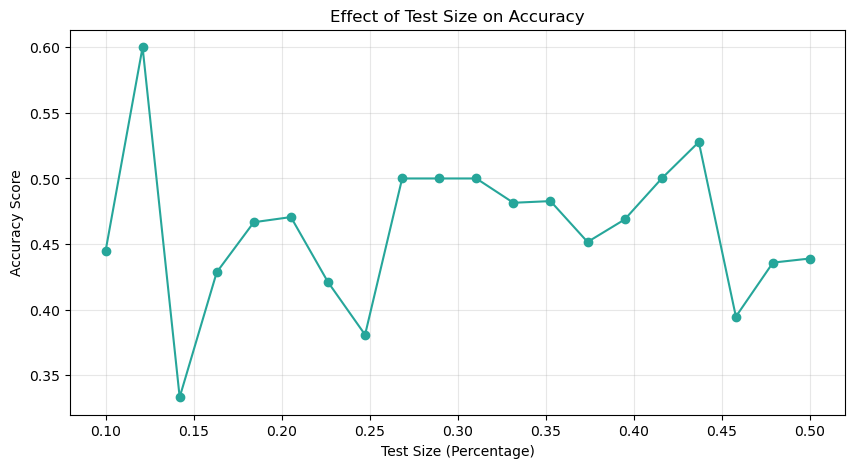

In [117]:
# Range of test sizes from 10% to 50%
test_sizes = np.linspace(0.1, 0.5, 20)
accuracies = []

for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=0)
    
    # Scaling must be inside the loop because the training set changes
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(test_sizes, accuracies, marker='o', color='#26a69a', linestyle='-')
plt.title('Effect of Test Size on Accuracy')
plt.xlabel('Test Size (Percentage)')
plt.ylabel('Accuracy Score')
plt.grid(True, alpha=0.3)
plt.show()

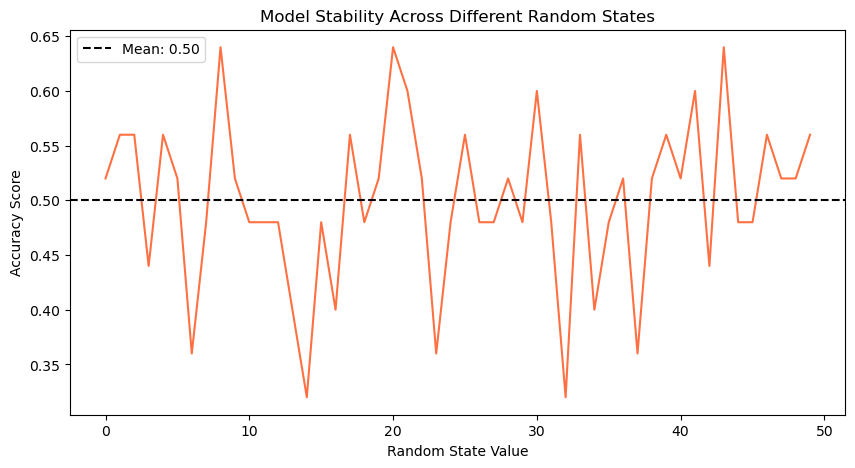

In [119]:
# Testing 50 different random splits
random_states = range(0, 50)
rs_accuracies = []

for rs in random_states:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rs)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    rs_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(random_states, rs_accuracies, color='#ff7043')
plt.axhline(y=np.mean(rs_accuracies), color='black', linestyle='--', label=f'Mean: {np.mean(rs_accuracies):.2f}')
plt.title('Model Stability Across Different Random States')
plt.xlabel('Random State Value')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [77]:
'''KNN with random number of neighbors'''

# 1. Instantiate the class with a specific number of neighbors (e.g., 3)
clf = KNeighborsClassifier(n_neighbors=3) 

# 2. Fit the model using the scaled training data
clf.fit(X_train, y_train) 

# 3. Evaluate the results
print("Train set accuracy: {:.2f}".format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Train set accuracy: 0.73
Test set accuracy: 0.60


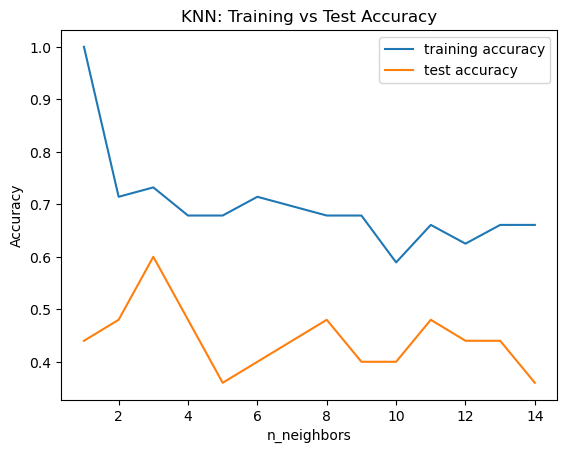

In [78]:
'''graphing the KNN: Training vs Test Accuracy (Monte Carlo Cross Validation)'''

training_accuracy = []
test_accuracy = []

# Try n_neighbors from 1 to 15 
neighbors_settings = range(1, 15)

for n_neighbors in neighbors_settings:
    # Build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    
    # Record training set accuracy
    training_accuracy.append(clf.score(X_train, y_train))
    # Record generalization (test) accuracy
    test_accuracy.append(clf.score(X_test, y_test))

# Plotting
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.title("KNN: Training vs Test Accuracy")
plt.legend()
plt.show()

In [81]:
'''Prof Gino's method (same thing but larger range)'''

lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()
for seedN in range(1, 50, 1):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.3, random_state=0
                                        )
    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50) # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

    lahat_training[seedN]=training_accuracy
    lahat_test[seedN] = test_accuracy

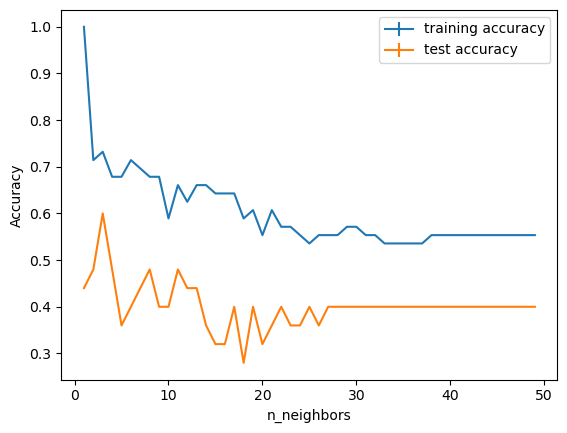

In [82]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [95]:
'''Random Forest Classifier''' 

# Making the Model 
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees (default) 
    max_depth=None,         # max depth of each tree (None = expand until all leaves are pure)
    random_state=30,        # for reproducibility (followed the same num as in logistic regression)
    n_jobs=-1               # use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.48



Logistic Regression Confusion Matrix:
[[ 5  6]
 [ 4 10]]

KNN Confusion Matrix:
[[11  0]
 [14  0]]

Random Forest Confusion Matrix:
[[10  1]
 [11  3]]


C:\Users\jlgel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\jlgel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


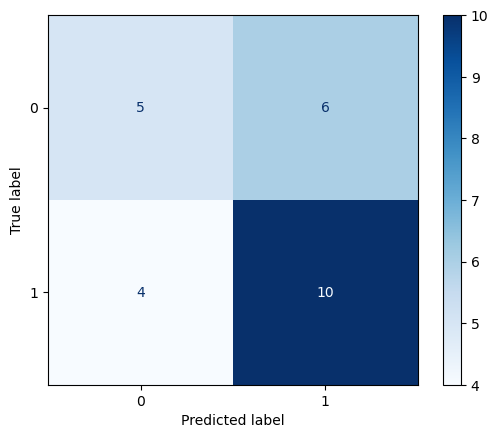

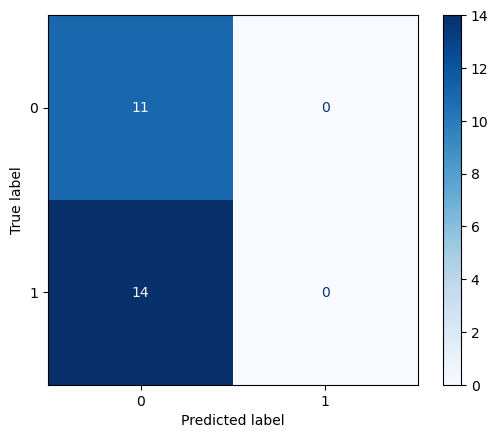

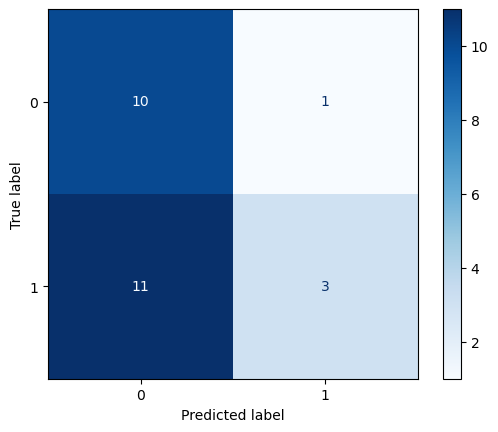

In [105]:
'''Confusion Matrix'''

models = {
    "Logistic Regression": logreg_model,
    "KNN": clf,
    "Random Forest": rf_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)  # predictions
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')  # nice blue color for visualization